# Clase 20: Griegas

> **Objetivo:** Calcular e interpretar las cinco griegas principales. Entender cómo cada una mide una dimensión distinta de riesgo y cómo se usan para gestionar posiciones con opciones en la práctica.
> 

---

## 1. ¿Qué son las griegas?

El precio de una opción depende de varios factores simultáneamente: el precio del subyacente, el tiempo que queda, la volatilidad implícita y la tasa libre de riesgo. Si cualquiera de esos factores cambia, el precio de la opción cambia.

Las **griegas** miden exactamente eso, cuánto cambia el precio de la opción cuando cada factor se mueve una unidad, manteniendo los demás constantes. Son las herramientas con las que un inversionista gestiona el riesgo de una posición en tiempo real, sin esperar al vencimiento.

| Griega | Factor que mide | Pregunta que responde |
| --- | --- | --- |
| **Delta** Δ | Precio del subyacente | Si SPY sube $1, ¿cuánto cambia mi opción? |
| **Gamma** Γ | Cambio en delta | ¿Qué tan rápido cambia mi delta? |
| **Vega** ν | Volatilidad implícita | Si IV sube 1%, ¿cuánto cambia mi opción? |
| **Theta** Θ | Tiempo | ¿Cuánto pierde mi opción por el paso de un día? |
| **Rho** ρ | Tasa libre de riesgo | Si las tasas suben 1%, ¿cuánto cambia mi opción? |

![info-options_greeks-desktop.png](attachment:b9650f73-11e3-4d9e-86b5-05dd89e0b714:info-options_greeks-desktop.png)

## 1. Delta (Δ)

Delta es la griega más importante. Mide cuánto se mueve el precio de la opción cuando el subyacente se mueve $1. Una delta de 0.45 significa que si SPY sube $1, el call sube aproximadamente $0.45.

Tiene dos interpretaciones simultáneas que son igualmente válidas:

**Como sensibilidad al precio:** si tienes 10 contratos (100 titulos c/u) de un call con delta = 0.45, tu posición se comporta como si tuvieras 450 acciones de SPY, en términos de exposición a un movimiento del precio.

**Como probabilidad aproximada de terminar ITM:** una call ATM tiene delta ≈ 0.50, el mercado asigna aproximadamente 50% de probabilidad de que SPY cierre por encima del strike. Una call muy ITM tiene delta ≈ 1.0.

### Fórmula

$$
\Delta_{\text{call}} = N(d_1) \qquad \Delta_{\text{put}} = N(d_1) - 1
$$

Delta de un call siempre está entre 0 y 1. Delta de un put siempre está entre -1 y 0, el put sube cuando el subyacente baja.

### Delta y cobertura

Si quieres una posición **delta-neutral**, que no gane ni pierda por movimientos pequeños del precio, necesitas compensar la delta de tu opción con una posición en el subyacente.

Por ejemplo: tienes 1 long call con delta = 0.45. Para ser delta-neutral, vendes 0.45 acciones de SPY. Ahora un movimiento de $1 en SPY genera +$0.45 en el call y -$0.45 en las acciones vendidas, el efecto neto es cero.

Este proceso se llama **delta hedging** y es la base del trabajo de un market maker de opciones.

---

## 2. Gamma (Γ)

Gamma mide cuánto cambia delta cuando el subyacente se mueve $1. Es la curvatura de la posición.

Si delta es la velocidad, gamma es la aceleración.

Un call ATM con delta = 0.45 y gamma = 0.02 significa que si SPY sube $1, la delta ya no es 0.45 sino aproximadamente 0.47. Esto importa para la cobertura: si tu posición tiene gamma alta, tu delta cambia rápido y necesitas rebalancear frecuentemente.

### Fórmula

$$
\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}
$$

Gamma es **idéntica** para calls y puts con el mismo strike y vencimiento, es una propiedad de la estructura del payoff, no del tipo de opción. Es máxima cuando la opción está ATM y cuando queda poco tiempo al vencimiento.

### Long vs. short gamma

Comprar opciones (long) implica tener **gamma positiva**: te beneficias de los movimientos grandes en cualquier dirección, si el subyacente sube mucho, tu delta sube y ganas más de lo que predecía el delta lineal; si baja mucho, tu delta baja y pierdes menos.

Vender opciones (short) implica tener **gamma negativa**: los movimientos grandes en cualquier dirección te perjudican.

---

## 3. Vega (ν)

Vega mide cuánto cambia el precio de la opción cuando la volatilidad implícita sube 1%. Una vega de 0.25 significa que si IV sube de 16.87% a 17.87%, el call sube $0.25.

Vega es positiva para posiciones long y negativa para posiciones short. Es la griega central del **trading de volatilidad**, cuando un trader dice que “está comprando vol”, está construyendo una posición con vega positiva: si la IV sube, gana dinero aunque el precio no se mueva.

La conexión con la superficie de volatilidad de la Clase 17 es directa: cada punto de la superficie tiene su propio vega, las opciones de largo plazo tienen más vega que las de corto plazo porque tienen más tiempo para que la IV cambie.

### Fórmula

$$
\nu = \frac{S \cdot N'(d_1) \cdot \sqrt{T}}{100}
$$

El divisor 100 convierte la unidad a “cambio por 1 punto porcentual de IV”.

---

## 4. Theta (Θ)

Theta mide cuánto pierde la opción por el simple paso de un día, manteniendo todo lo demás constante. Es el **costo del tiempo**, las opciones son activos que se deprecian diariamente.

Para posiciones long, theta es negativa: pagas tiempo todos los días. Para posiciones short, theta es positiva: cobras tiempo todos los días. Esto crea el dilema central del trading de opciones: quien compra opciones paga theta pero tiene gamma positiva; quien las vende cobra theta pero asume gamma negativa.

$$
\Theta \approx -\frac{1}{2} \Gamma S^2 \sigma^2
$$

Esta relación no es coincidencia, es una consecuencia directa de la ecuación de Black-Scholes. No existe almuerzo gratis: la prima que cobras vendiendo opciones es exactamente la compensación por el riesgo gamma que asumes.

Theta se acelera conforme se acerca el vencimiento, el *time decay* es máximo en los últimos días de vida de una opción ATM. Por eso los vendedores de opciones prefieren vender opciones de corto plazo.

---

## 5. Rho (ρ)

Rho mide la sensibilidad al cambio en la tasa libre de riesgo. Es la griega menos importante para opciones de corto plazo, una subida de 1% en tasas mueve el precio de una call de 31 días apenas unos centavos. Se vuelve relevante en opciones de largo plazo (más de 6 meses) donde el descuento del strike importa más.

Para calls, rho es positivo: tasas más altas hacen que el call sea más atractivo porque el costo de financiar el subyacente aumenta. Para puts, rho es negativo.

---

## 7. Código


Griega       Valor  Interpretación
delta       0.4076  Si SPY sube $1, el call sube $0.4076
gamma       0.0118  Delta cambia0.0118 por cada $1 de SPY
vega        0.7569  Si IV sube 1%, el call sube $0.7569
theta      -0.2363  El call pierde $0.2363 por día
rho         0.2237  Si tasas suben 1%, el call cambia $0.2237


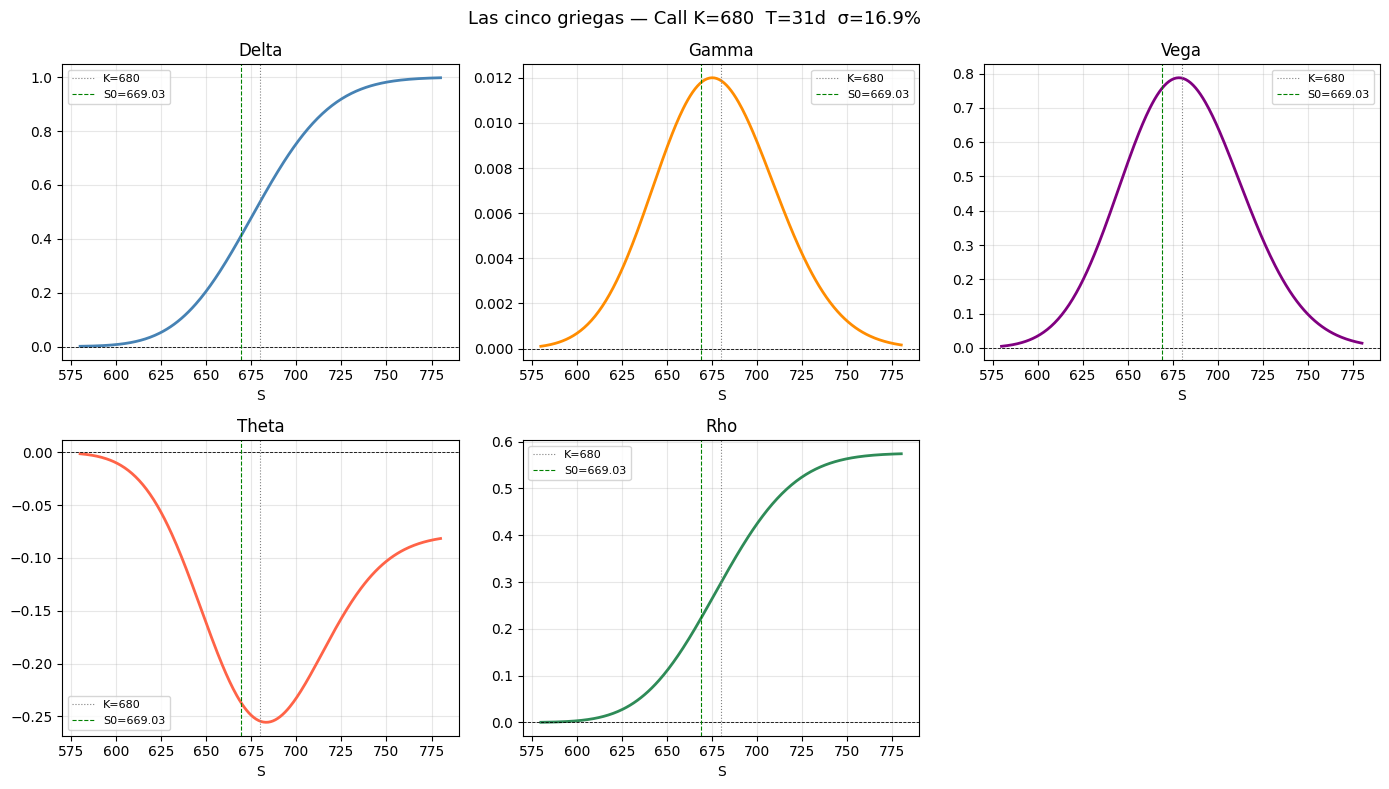

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def greeks(S, K, r, T, sigma, option='call'):
    if T <= 0 or sigma <= 0:
        return {k: 0 for k in ['delta','gamma','vega','theta','rho']}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    if option == 'call':
        delta = norm.cdf(d1)
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
        rho   =  K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta, 'rho': rho}

# Parámetros
S0, K, r, T, sigma = 669.03, 680, 0.042, 31/365, 0.1687

# Griegas en el punto actual
g = greeks(S0, K, r, T, sigma, 'call')
print(f"{'Griega':<8}{'Valor':>10}  Interpretación")
print(f"{'delta':<8}{g['delta']:>10.4f}  Si SPY sube $1, el call sube ${g['delta']:.4f}")
print(f"{'gamma':<8}{g['gamma']:>10.4f}  Delta cambia{g['gamma']:.4f} por cada $1 de SPY")
print(f"{'vega':<8}{g['vega']:>10.4f}  Si IV sube 1%, el call sube ${g['vega']:.4f}")
print(f"{'theta':<8}{g['theta']:>10.4f}  El call pierde ${abs(g['theta']):.4f} por día")
print(f"{'rho':<8}{g['rho']:>10.4f}  Si tasas suben 1%, el call cambia ${g['rho']:.4f}")

# Plot de las 5 griegas vs. precio
S_range  = np.linspace(580, 780, 300)
metricas = ['delta', 'gamma', 'vega', 'theta', 'rho']
colores  = ['steelblue', 'darkorange', 'purple', 'tomato', 'seagreen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (m, c) in enumerate(zip(metricas, colores)):
    vals = [greeks(s, K, r, T, sigma, 'call')[m] for s in S_range]
    axes[i].plot(S_range, vals, color=c, linewidth=2)
    axes[i].axhline(0,  color='black', linewidth=0.6, linestyle='--')
    axes[i].axvline(K,  color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    axes[i].axvline(S0, color='green', linewidth=0.8, linestyle='--', label=f'S0={S0}')
    axes[i].set_title(m.capitalize())
    axes[i].set_xlabel('S')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[5].axis('off')
plt.suptitle(f'Las cinco griegas — Call K={K}  T={round(T*365)}d  σ={sigma:.1%}', fontsize=13)
plt.tight_layout()
plt.show()